In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [181]:
df1 = pd.read_csv("student-mat.csv", sep=";")
df2 = pd.read_csv("student-por.csv", sep=";")

In [182]:
df = pd.merge(
    df1,
    df2,
    on=["school","sex","age","address","famsize","Pstatus",
        "Medu","Fedu","Mjob","Fjob","reason","nursery","internet","guardian","traveltime","romantic","freetime",
                   "famrel","goout","Dalc","Walc","health","absences"], suffixes=('_math', '_por')
)

In [183]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,studytime_por,failures_por,schoolsup_por,famsup_por,paid_por,activities_por,higher_por,G1_por,G2_por,G3_por
0,GP,M,16,U,LE3,T,2,2,other,other,...,2,0,no,no,no,no,yes,13,12,13
1,GP,M,15,U,LE3,A,3,2,services,other,...,2,0,no,yes,no,no,yes,15,16,17
2,GP,M,15,U,GT3,T,3,4,other,other,...,2,0,no,yes,no,yes,yes,12,12,13
3,GP,M,15,U,GT3,A,2,2,other,other,...,3,0,no,yes,no,no,yes,14,14,15
4,GP,M,15,U,GT3,T,4,3,teacher,other,...,2,0,no,no,no,no,yes,12,13,14


## Data Preprocessing 

In [184]:
df.isnull().sum()

school             0
sex                0
age                0
address            0
famsize            0
Pstatus            0
Medu               0
Fedu               0
Mjob               0
Fjob               0
reason             0
guardian           0
traveltime         0
studytime_math     0
failures_math      0
schoolsup_math     0
famsup_math        0
paid_math          0
activities_math    0
nursery            0
higher_math        0
internet           0
romantic           0
famrel             0
freetime           0
goout              0
Dalc               0
Walc               0
health             0
absences           0
G1_math            0
G2_math            0
G3_math            0
studytime_por      0
failures_por       0
schoolsup_por      0
famsup_por         0
paid_por           0
activities_por     0
higher_por         0
G1_por             0
G2_por             0
G3_por             0
dtype: int64

In [185]:
df.duplicated().sum()

0

In [186]:
df=df.drop(columns=['school','address'])

In [187]:
df.head(5)

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,...,studytime_por,failures_por,schoolsup_por,famsup_por,paid_por,activities_por,higher_por,G1_por,G2_por,G3_por
0,M,16,LE3,T,2,2,other,other,home,mother,...,2,0,no,no,no,no,yes,13,12,13
1,M,15,LE3,A,3,2,services,other,home,mother,...,2,0,no,yes,no,no,yes,15,16,17
2,M,15,GT3,T,3,4,other,other,home,mother,...,2,0,no,yes,no,yes,yes,12,12,13
3,M,15,GT3,A,2,2,other,other,home,other,...,3,0,no,yes,no,no,yes,14,14,15
4,M,15,GT3,T,4,3,teacher,other,reputation,mother,...,2,0,no,no,no,no,yes,12,13,14


In [188]:
df.columns

Index(['sex', 'age', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob',
       'reason', 'guardian', 'traveltime', 'studytime_math', 'failures_math',
       'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math',
       'nursery', 'higher_math', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1_math', 'G2_math',
       'G3_math', 'studytime_por', 'failures_por', 'schoolsup_por',
       'famsup_por', 'paid_por', 'activities_por', 'higher_por', 'G1_por',
       'G2_por', 'G3_por'],
      dtype='str')

In [189]:
df.dtypes

sex                  str
age                int64
famsize              str
Pstatus              str
Medu               int64
Fedu               int64
Mjob                 str
Fjob                 str
reason               str
guardian             str
traveltime         int64
studytime_math     int64
failures_math      int64
schoolsup_math       str
famsup_math          str
paid_math            str
activities_math      str
nursery              str
higher_math          str
internet             str
romantic             str
famrel             int64
freetime           int64
goout              int64
Dalc               int64
Walc               int64
health             int64
absences           int64
G1_math            int64
G2_math            int64
G3_math            int64
studytime_por      int64
failures_por       int64
schoolsup_por        str
famsup_por           str
paid_por             str
activities_por       str
higher_por           str
G1_por             int64
G2_por             int64


In [190]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
con_colum=df.select_dtypes(include=['int64']).columns.tolist()
print(cat_cols)

['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math', 'nursery', 'higher_math', 'internet', 'romantic', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por']


In [191]:
ordinal=['Medu', 'Fedu','famrel', 'freetime','goout', 'Dalc', 'Walc', 'health']

for col in ordinal:
    if col in cat_cols:
        cat_cols.remove(col)
    else : 
        pass

    if col in con_colum:
        con_colum.remove(col)
    else :
        pass
    
        
print("Cat_cols:",cat_cols) 
print("Con_cols:",con_colum)
print("Ordinalcolumns:",ordinal)

Cat_cols: ['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math', 'nursery', 'higher_math', 'internet', 'romantic', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por']
Con_cols: ['age', 'traveltime', 'studytime_math', 'failures_math', 'absences', 'G1_math', 'G2_math', 'G3_math', 'studytime_por', 'failures_por', 'G1_por', 'G2_por', 'G3_por']
Ordinalcolumns: ['Medu', 'Fedu', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


# EDA

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns


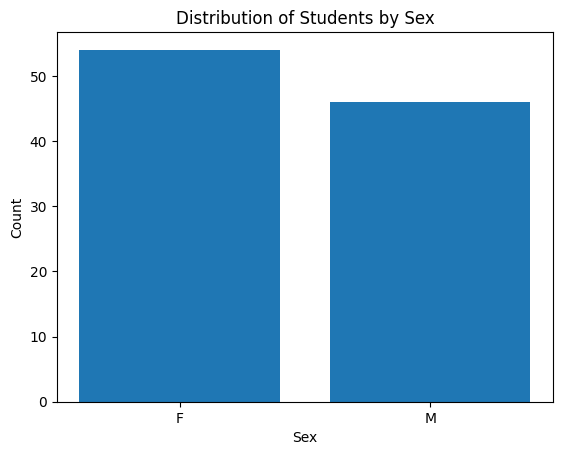

In [193]:
counts = df['sex'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Students by Sex')
plt.show()

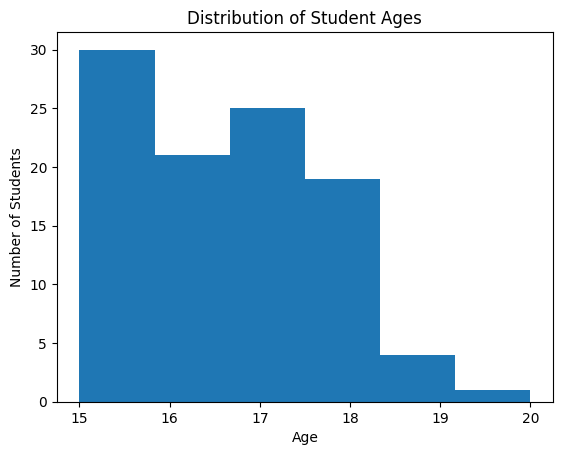

In [194]:
plt.hist(df['age'], bins=len(df['age'].unique()))
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.title('Distribution of Student Ages')
plt.show()

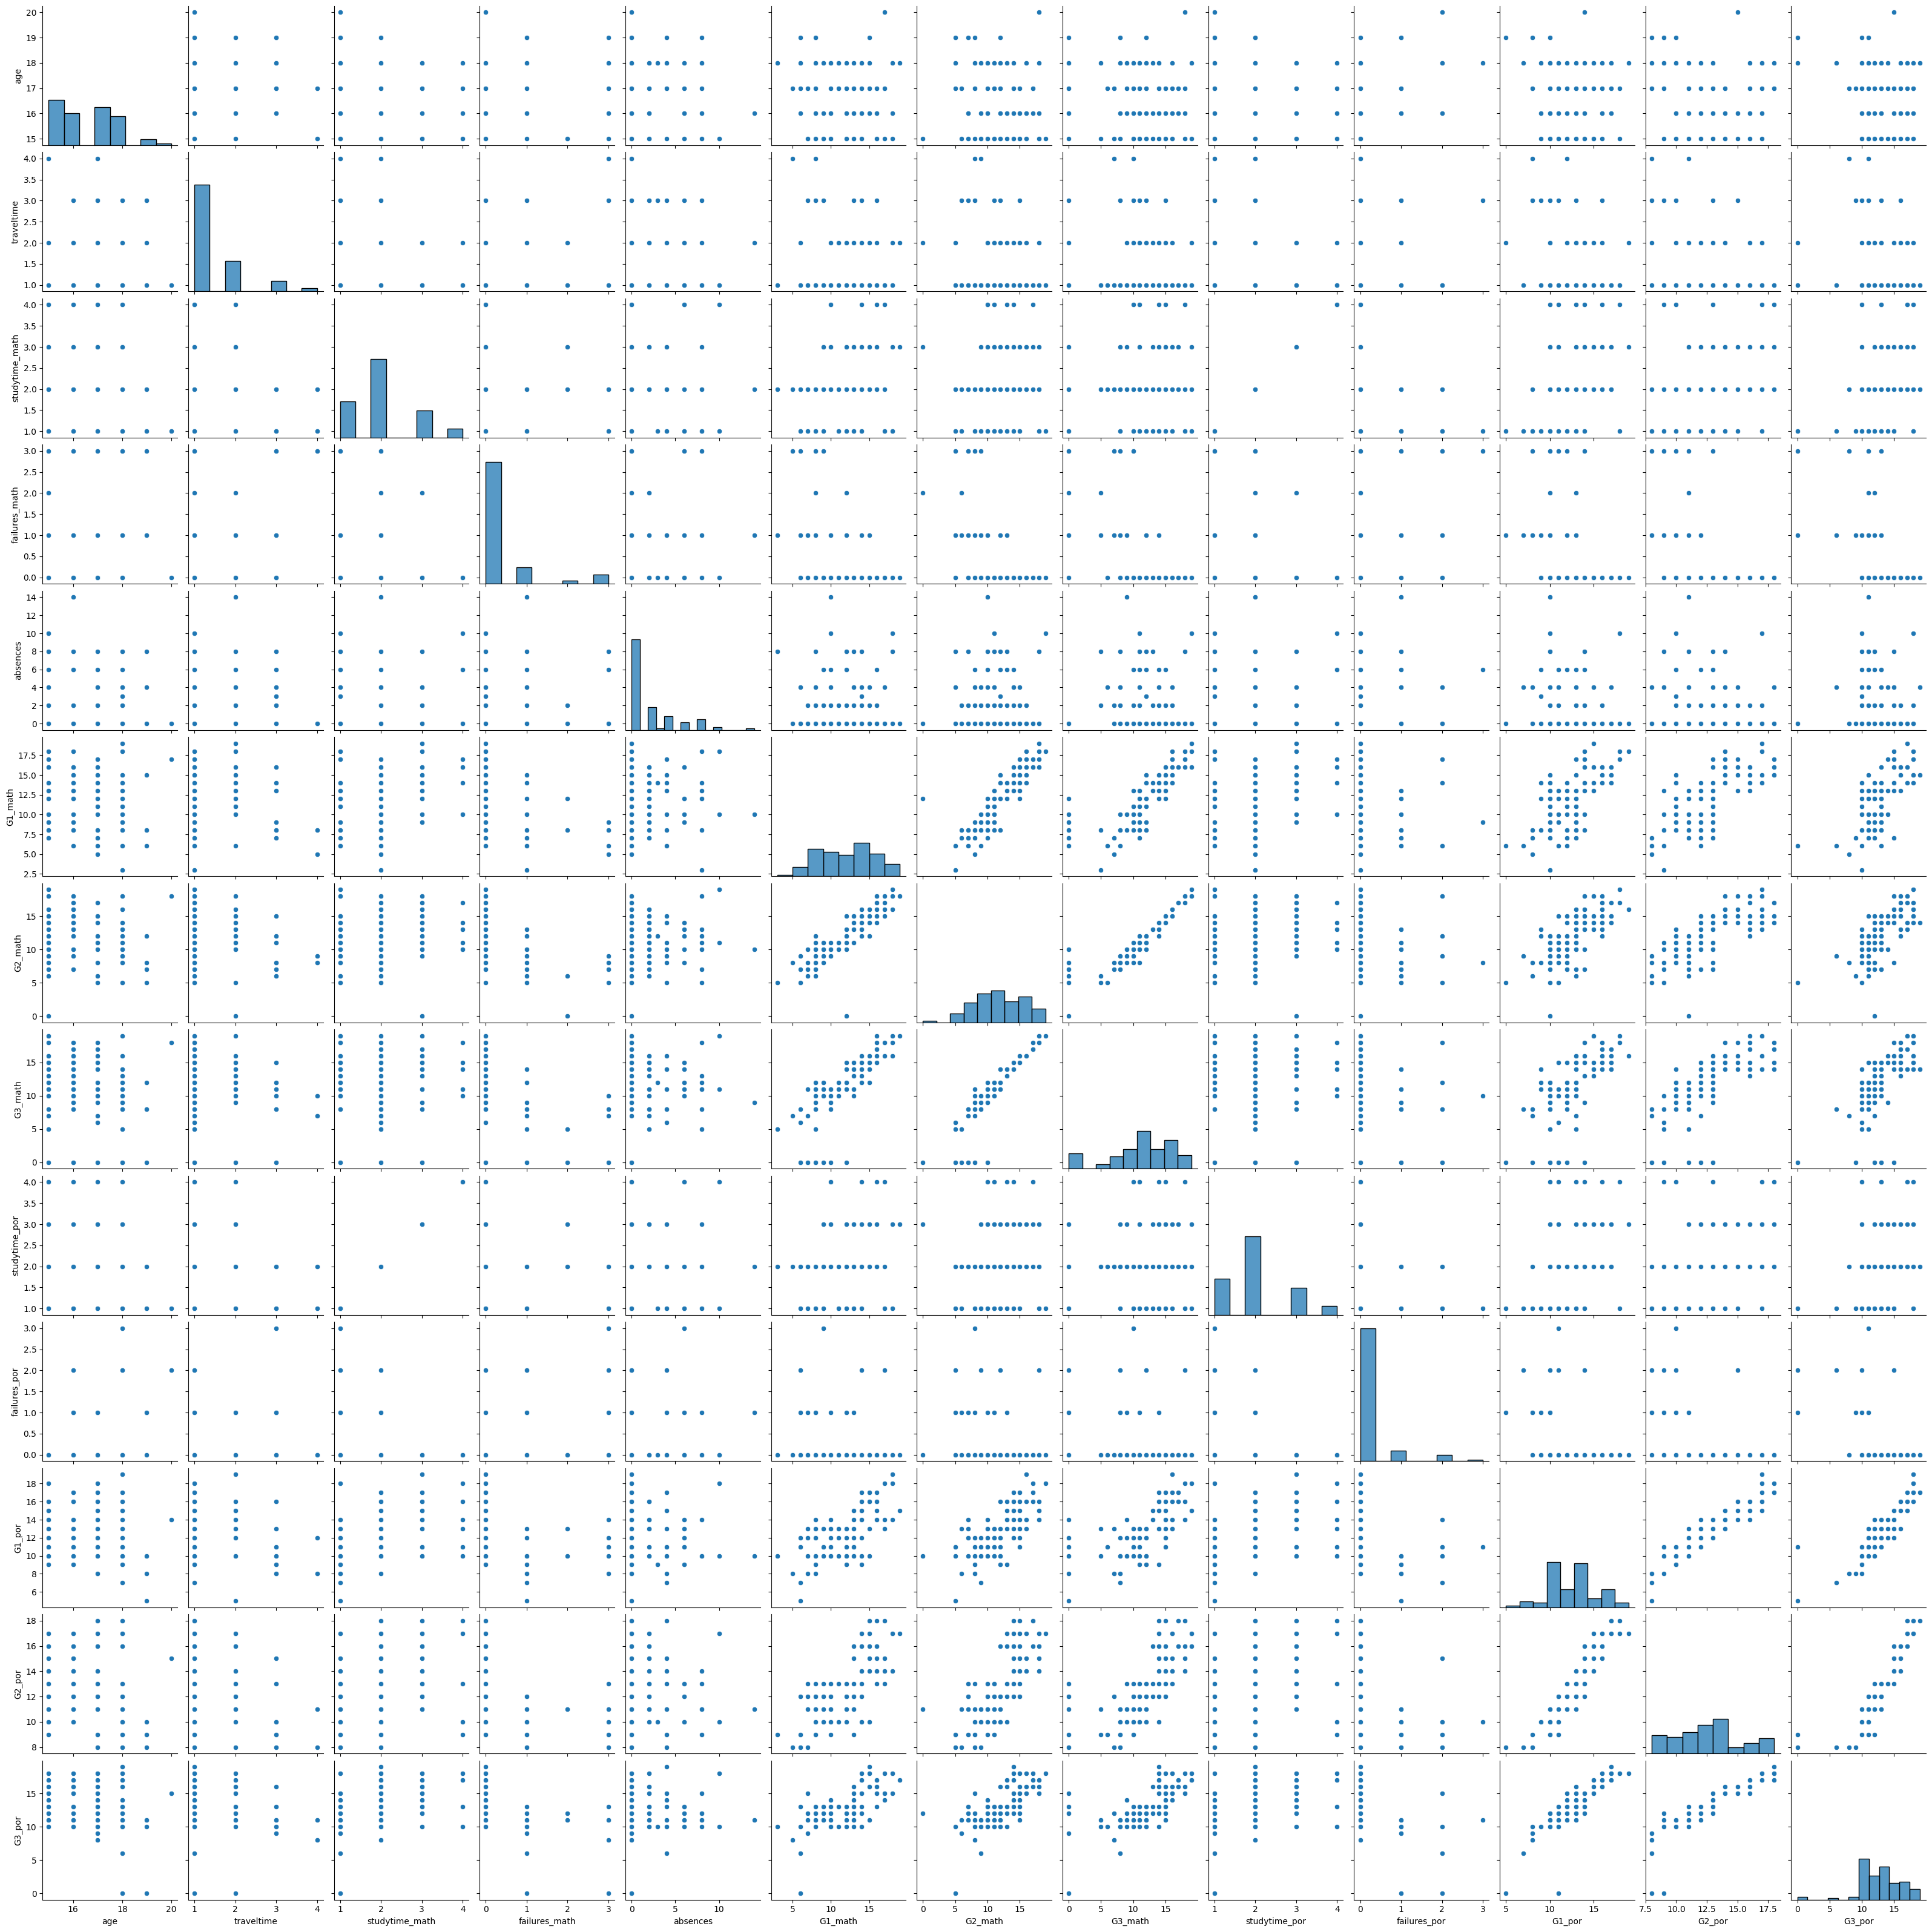

In [195]:
sns.pairplot(df[con_colum])
plt.show()

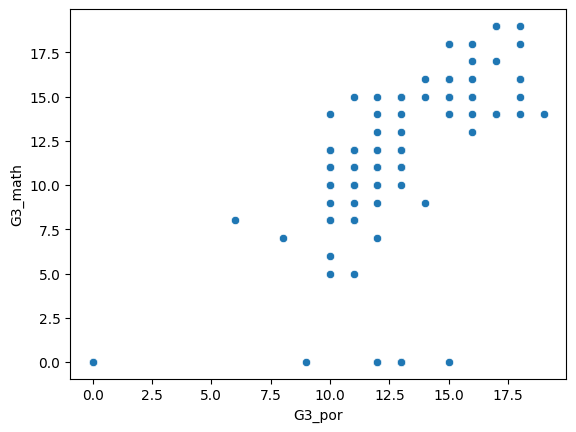

In [196]:
sns.scatterplot(data=df,x='G3_por',y='G3_math')
plt.show()

In [197]:
df_cat=pd.get_dummies(df[cat_cols],dtype=int,drop_first=False)
df_cat.head()

,sex_F,sex_M,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,...,schoolsup_por_no,schoolsup_por_yes,famsup_por_no,famsup_por_yes,paid_por_no,paid_por_yes,activities_por_no,activities_por_yes,higher_por_no,higher_por_yes
0,0,1,0,1,0,1,0,0,1,0,...,1,0,1,0,1,0,1,0,0,1
1,0,1,0,1,1,0,0,0,0,1,...,1,0,0,1,1,0,1,0,0,1
2,0,1,1,0,0,1,0,0,1,0,...,1,0,0,1,1,0,0,1,0,1
3,0,1,1,0,1,0,0,0,1,0,...,1,0,0,1,1,0,1,0,0,1
4,0,1,1,0,0,1,0,0,0,0,...,1,0,1,0,1,0,1,0,0,1


In [198]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_con=scaler.fit_transform(df[con_colum])
df_con=pd.DataFrame(df_con,columns=con_colum)
df_con.head()

,age,traveltime,studytime_math,failures_math,absences,G1_math,G2_math,G3_math,studytime_por,failures_por,G1_por,G2_por,G3_por
0,-0.388607,-0.565685,-0.074057,-0.418729,-0.637195,0.094320,0.094428,-0.047428,-0.074057,-0.335643,0.200154,-0.190878,0.073183
1,-1.181684,-0.565685,-0.074057,-0.418729,-0.637195,1.237593,1.760812,1.602246,-0.074057,-0.335643,0.969977,1.367312,1.345940
2,-1.181684,-0.565685,-0.074057,-0.418729,-0.637195,0.665956,0.927620,0.777409,-0.074057,-0.335643,-0.184758,-0.190878,0.073183
3,-1.181684,-0.565685,1.160229,-0.418729,-0.637195,0.665956,1.205351,0.983618,1.160229,-0.335643,0.585066,0.588217,0.709562
4,-1.181684,-0.565685,-0.074057,-0.418729,-0.637195,0.380138,0.649890,0.777409,-0.074057,-0.335643,-0.184758,0.198669,0.391373


In [199]:
df_prepos = pd.concat([df_cat, df_con], axis=1)
df_prepos.head()

,sex_F,sex_M,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,...,failures_math,absences,G1_math,G2_math,G3_math,studytime_por,failures_por,G1_por,G2_por,G3_por
0,0,1,0,1,0,1,0,0,1,0,...,-0.418729,-0.637195,0.094320,0.094428,-0.047428,-0.074057,-0.335643,0.200154,-0.190878,0.073183
1,0,1,0,1,1,0,0,0,0,1,...,-0.418729,-0.637195,1.237593,1.760812,1.602246,-0.074057,-0.335643,0.969977,1.367312,1.345940
2,0,1,1,0,0,1,0,0,1,0,...,-0.418729,-0.637195,0.665956,0.927620,0.777409,-0.074057,-0.335643,-0.184758,-0.190878,0.073183
3,0,1,1,0,1,0,0,0,1,0,...,-0.418729,-0.637195,0.665956,1.205351,0.983618,1.160229,-0.335643,0.585066,0.588217,0.709562
4,0,1,1,0,0,1,0,0,0,0,...,-0.418729,-0.637195,0.380138,0.649890,0.777409,-0.074057,-0.335643,-0.184758,0.198669,0.391373


In [200]:
#!pip install gower


In [201]:
# apply K-modoids Clustering

In [202]:
# import gower

# gower_dist = gower.gower_matrix(df_prepos)

In [203]:
# print("Gower Distance Matrix:\n")
# print(gower_dist)

In [204]:
#Suorvise ML Analysisn

In [205]:
cols=df.columns
print(cols)

Index(['sex', 'age', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob',
       'reason', 'guardian', 'traveltime', 'studytime_math', 'failures_math',
       'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math',
       'nursery', 'higher_math', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1_math', 'G2_math',
       'G3_math', 'studytime_por', 'failures_por', 'schoolsup_por',
       'famsup_por', 'paid_por', 'activities_por', 'higher_por', 'G1_por',
       'G2_por', 'G3_por'],
      dtype='str')


In [206]:
por_list = [col for col in cols if col.endswith('_por')]
math_list = [col for col in cols if col.endswith('_math')]

print("POR columns:", por_list)
print("MATH columns:", math_list)

POR columns: ['studytime_por', 'failures_por', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por', 'G1_por', 'G2_por', 'G3_por']
MATH columns: ['studytime_math', 'failures_math', 'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math', 'higher_math', 'G1_math', 'G2_math', 'G3_math']


## maths final marks predictions 

In [207]:

df_math=df.drop(columns=por_list)

In [208]:
df_math.head()

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1_math,G2_math,G3_math
0,M,16,LE3,T,2,2,other,other,home,mother,...,4,4,4,1,1,3,0,12,12,11
1,M,15,LE3,A,3,2,services,other,home,mother,...,4,2,2,1,1,1,0,16,18,19
2,M,15,GT3,T,3,4,other,other,home,mother,...,5,5,1,1,1,5,0,14,15,15
3,M,15,GT3,A,2,2,other,other,home,other,...,4,5,2,1,1,3,0,14,16,16
4,M,15,GT3,T,4,3,teacher,other,reputation,mother,...,4,4,1,1,1,1,0,13,14,15


In [209]:
cat_cols = df_math.select_dtypes(include=['str']).columns.tolist()
con_colum=df_math.select_dtypes(include=['int64']).columns.tolist()
print(cat_cols)
print(con_colum)

['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math', 'nursery', 'higher_math', 'internet', 'romantic']
['age', 'Medu', 'Fedu', 'traveltime', 'studytime_math', 'failures_math', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1_math', 'G2_math', 'G3_math']


In [210]:
ordinal=['Medu', 'Fedu','famrel', 'freetime','goout', 'Dalc', 'Walc', 'health']

for col in ordinal:
    if col in cat_cols:
        cat_cols.remove(col)
    else : 
        pass

    if col in con_colum:
        con_colum.remove(col)
    else :
        pass
    
        
print("Cat_cols:",cat_cols) 
print("Con_cols:",con_colum)
print("Ordinalcolumns:",ordinal)
    

Cat_cols: ['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup_math', 'famsup_math', 'paid_math', 'activities_math', 'nursery', 'higher_math', 'internet', 'romantic']
Con_cols: ['age', 'traveltime', 'studytime_math', 'failures_math', 'absences', 'G1_math', 'G2_math', 'G3_math']
Ordinalcolumns: ['Medu', 'Fedu', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


In [211]:
from sklearn.preprocessing import StandardScaler

df_cat=pd.get_dummies(df_math[cat_cols],drop_first=True,dtype=int)
scaler=StandardScaler()
df_con=scaler.fit_transform(df_math[con_colum])
df_con = pd.DataFrame(
    scaler.fit_transform(df_math[con_colum]), 
    columns=df_math[con_colum].columns, 
    index=df.index
)
df_prepo = pd.concat([df_cat, df_con, df[ordinal]], axis=1)

In [212]:
df_prepo.head()

,sex_M,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,...,G2_math,G3_math,Medu,Fedu,famrel,freetime,goout,Dalc,Walc,health
0,1,1,1,0,1,0,0,0,1,0,...,0.094428,-0.047428,2,2,4,4,4,1,1,3
1,1,1,0,0,0,1,0,0,1,0,...,1.760812,1.602246,3,2,4,2,2,1,1,1
2,1,0,1,0,1,0,0,0,1,0,...,0.927620,0.777409,3,4,5,5,1,1,1,5
3,1,0,0,0,1,0,0,0,1,0,...,1.205351,0.983618,2,2,4,5,2,1,1,3
4,1,0,1,0,0,0,1,0,1,0,...,0.649890,0.777409,4,3,4,4,1,1,1,1


In [213]:
from sklearn.model_selection import train_test_split
y=df_prepo['G3_math']
X=df_prepo.drop(columns='G3_math')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=268386)

In [214]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [215]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

In [216]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model      RMSE  R2 Score
4      Random Forest  0.455447  0.773412
5  Gradient Boosting  0.498325  0.728739
1              Ridge  0.620012  0.580084
3      Decision Tree  0.647729  0.541701
0  Linear Regression  0.730736  0.416712
2              Lasso  0.958004 -0.002529


### Hyper-parameter Tuning 

In [217]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': np.arange(0.01, 0.2, 0.01),
    'max_depth': [3, 5, 7],
}

gb_model = GradientBoostingRegressor()

grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [218]:
grid_search.fit(X_train,y_train)

C:\Users\Danuka\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.01, ..., 0.18, 0.19]), 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [219]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [220]:
r2_score(y_test,y_pred_best)

0.4637676957519008

In [221]:
mean_squared_error(y_test,y_pred_best)

0.4908975042326728

In [222]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator: RandomForestRegressor(max_depth=10)


In [223]:
y_pred=grid_search.predict(X_test)

In [224]:
Y_train_pred=grid_search.predict(X_train)
np.sqrt(mean_squared_error(y_train,Y_train_pred))

0.19761304494999987

In [225]:
r2_score(y_test,y_pred)

0.7674261457473163

In [226]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.4614231400552829

In [227]:
import xgboost as xgb
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Training model
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [228]:
y_pred=model.predict(X_test)

In [229]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.4387054911562041

In [230]:
r2_score(y_test,y_pred)

0.7897634165165157

In [231]:
baseline_pred = [y_train.mean()] * len(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(baseline_rmse)

0.9580041183672084


## For Protugrees prediction


In [232]:

df_pro=df.drop(columns=math_list)

In [233]:
cat_pro=df_pro.select_dtypes(include=['str']).columns.tolist()
con_pro=df_pro.select_dtypes(include=['int64']).columns.tolist()

print('categprical:',cat_pro)
print('continuous:',con_pro)

categprical: ['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'nursery', 'internet', 'romantic', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por']
continuous: ['age', 'Medu', 'Fedu', 'traveltime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'studytime_por', 'failures_por', 'G1_por', 'G2_por', 'G3_por']


In [234]:
ordinal=['Medu', 'Fedu','famrel', 'freetime','goout', 'Dalc', 'Walc', 'health']

for col in ordinal:
    if col in cat_pro:
        cat_pro.remove(col)
    else : 
        pass

    if col in con_pro:
        con_pro.remove(col)
    else :
        pass
    
        
print("Cat_cols:",cat_pro) 
print("Con_cols:",con_pro)
print("Ordinalcolumns:",ordinal)

Cat_cols: ['sex', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'nursery', 'internet', 'romantic', 'schoolsup_por', 'famsup_por', 'paid_por', 'activities_por', 'higher_por']
Con_cols: ['age', 'traveltime', 'absences', 'studytime_por', 'failures_por', 'G1_por', 'G2_por', 'G3_por']
Ordinalcolumns: ['Medu', 'Fedu', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


In [235]:
df_cat=pd.get_dummies(df_pro[cat_pro],drop_first=True,dtype=int)
scaler=StandardScaler()
df_con=scaler.fit_transform(df_pro[con_pro])
df_con = pd.DataFrame(
    scaler.fit_transform(df_pro[con_pro]), 
    columns=df_pro[con_pro].columns, 
    index=df.index
)
df_prepo_pro = pd.concat([df_cat, df_con, df[ordinal]], axis=1)

In [236]:
df_prepo_pro.head()

,sex_M,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,...,G2_por,G3_por,Medu,Fedu,famrel,freetime,goout,Dalc,Walc,health
0,1,1,1,0,1,0,0,0,1,0,...,-0.190878,0.073183,2,2,4,4,4,1,1,3
1,1,1,0,0,0,1,0,0,1,0,...,1.367312,1.345940,3,2,4,2,2,1,1,1
2,1,0,1,0,1,0,0,0,1,0,...,-0.190878,0.073183,3,4,5,5,1,1,1,5
3,1,0,0,0,1,0,0,0,1,0,...,0.588217,0.709562,2,2,4,5,2,1,1,3
4,1,0,1,0,0,0,1,0,1,0,...,0.198669,0.391373,4,3,4,4,1,1,1,1


In [237]:
from sklearn.model_selection import train_test_split
y=df_prepo_pro['G3_por']
X=df_prepo_pro.drop(columns='G3_por')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=268386)

In [238]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model      RMSE  R2 Score
5  Gradient Boosting  0.713074  0.635363
1              Ridge  0.732112  0.615634
3      Decision Tree  0.746220  0.600678
0  Linear Regression  0.765795  0.579452
4      Random Forest  0.770988  0.573730
2              Lasso  1.295112 -0.202832


## Unsupervise ML